<a href="https://colab.research.google.com/github/yashkapur0403/Yash_Kapur_ML_Lab_Work/blob/main/nlp_ml_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

(18846, 2)


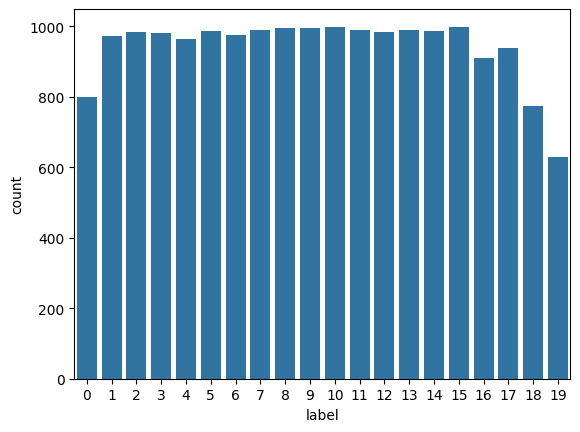

In [2]:
data = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))

df = pd.DataFrame({'text': data.data, 'label': data.target})

print(df.shape)

sns.countplot(x=df['label'])
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

              precision    recall  f1-score   support

           0       0.54      0.56      0.55       151
           1       0.65      0.64      0.65       202
           2       0.68      0.65      0.66       195
           3       0.59      0.63      0.61       183
           4       0.78      0.67      0.72       205
           5       0.79      0.75      0.77       215
           6       0.73      0.69      0.71       193
           7       0.71      0.69      0.70       196
           8       0.42      0.73      0.53       168
           9       0.81      0.82      0.81       211
          10       0.95      0.86      0.90       198
          11       0.87      0.73      0.79       201
          12       0.59      0.63      0.61       202
          13       0.75      0.83      0.79       194
          14       0.74      0.77      0.76       189
          15       0.67      0.75      0.71       202
          16       0.69      0.69      0.69       188
          17       0.80    

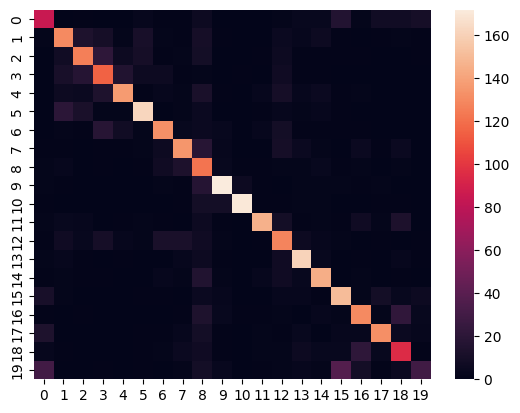

In [4]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm)
plt.show()

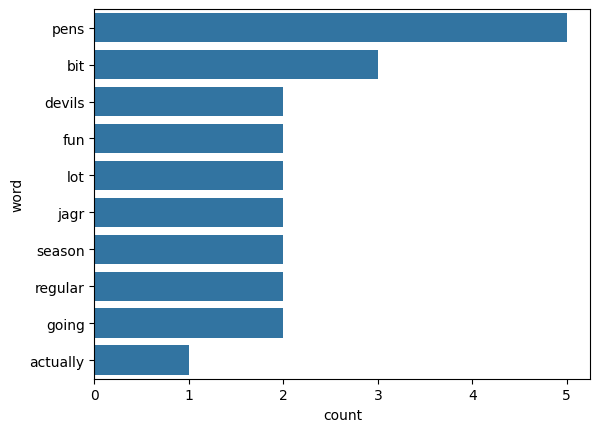

In [5]:
sample_text = df['text'].iloc[0]

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english')
X_counts = cv.fit_transform([sample_text])

words = cv.get_feature_names_out()
counts = X_counts.toarray().flatten()

freq_df = pd.DataFrame({'word': words, 'count': counts})
freq_df = freq_df.sort_values(by='count', ascending=False).head(10)

sns.barplot(x='count', y='word', data=freq_df)
plt.show()